/tmp/ipykernel_10325/692159421.py:84: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


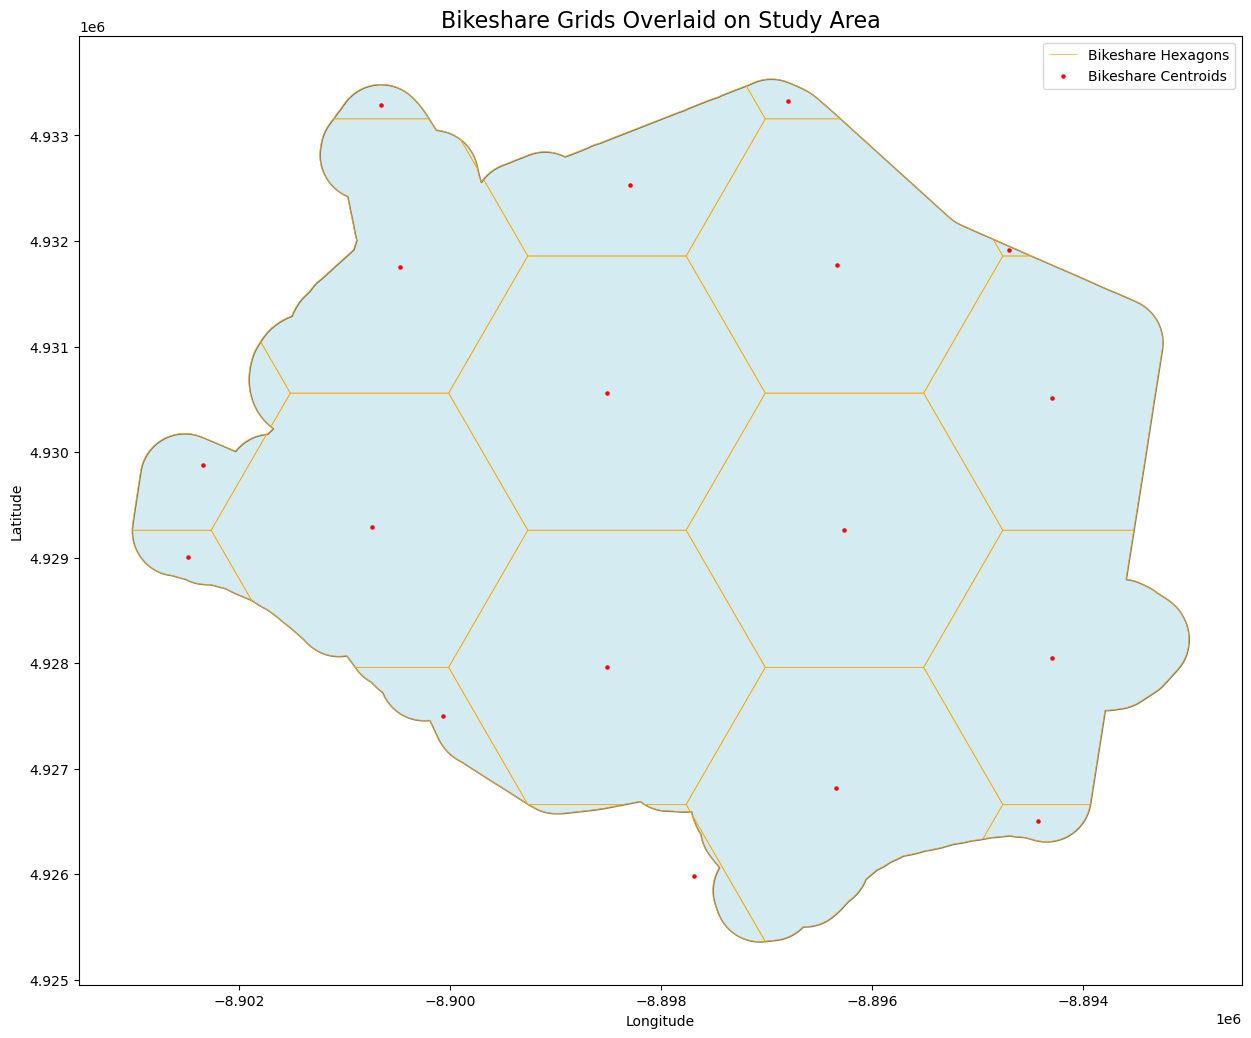

In [1]:
from pathlib import Path
import geopandas as gpd
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import numpy as np
from conf import config

def create_hex_grid(bounds, hex_size):
    """
    Create a hexagonal grid over the specified bounds.
    
    Parameters:
        bounds (tuple): (minx, miny, maxx, maxy) of the area
        hex_size (float): radius of the hexagons
        
    Returns:
        GeoDataFrame: GeoDataFrame with hexagonal grid polygons
    """
    minx, miny, maxx, maxy = bounds
    width = hex_size * 2
    height = np.sqrt(3) * hex_size
    cols = int((maxx - minx) / (3/4 * width)) + 1
    rows = int((maxy - miny) / height) + 1

    hexagons = []
    for col in range(cols):
        for row in range(rows):
            x = minx + col * (3/4 * width)
            y = miny + row * height
            if col % 2 == 1:  # Offset every other column
                y += height / 2

            # Create hexagon centered at (x, y)
            hexagon = Polygon([
                (x + hex_size * np.cos(angle), y + hex_size * np.sin(angle))
                for angle in np.linspace(0, 2 * np.pi, 7)
            ])
            hexagons.append(hexagon)

    return gpd.GeoDataFrame(geometry=hexagons)


# Load GeoDataFrame
study_area_gdf = gpd.read_file(config['paths']['data']['study_area_out']).to_crs("EPSG:3857")

# Define hexagon radii  (in the same units as study area CRS)
bikeshare_hex_size = 1500  # 1 km radius for bikeshare
microtransit_hex_size = 2000  # 4 km radius for microtransit

# Generate hexagonal grid for bikeshare
bikeshare_hex_grid = create_hex_grid(study_area_gdf.total_bounds, bikeshare_hex_size)
bikeshare_hex_grid = bikeshare_hex_grid.set_crs(study_area_gdf.crs, allow_override=True)
bikeshare_hex_grid_clipped = gpd.overlay(bikeshare_hex_grid, study_area_gdf, how='intersection')

# Generate centroids for bikeshare
bikeshare_hex_grid_clipped['centroid'] = bikeshare_hex_grid_clipped.geometry.centroid
bikeshare_centroids_gdf = bikeshare_hex_grid_clipped[['centroid']].copy().rename(columns={'centroid': 'geometry'})
bikeshare_centroids_gdf = gpd.GeoDataFrame(bikeshare_centroids_gdf, geometry='geometry', crs=bikeshare_hex_grid_clipped.crs)

# Generate hexagonal grid for microtransit
microtransit_hex_grid = create_hex_grid(study_area_gdf.total_bounds, microtransit_hex_size)
microtransit_hex_grid = microtransit_hex_grid.set_crs(study_area_gdf.crs, allow_override=True)
microtransit_hex_grid_clipped = gpd.overlay(microtransit_hex_grid, study_area_gdf, how='intersection')

# Add an ID column for microtransit hexagons
microtransit_hex_grid_clipped.insert(0, 'id', microtransit_hex_grid_clipped.index)

# Visualization of both grids
fig, ax = plt.subplots(figsize=(15, 15))

# Plot the study area
study_area_gdf.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.5, label='Study Area')

# Plot the bikeshare hexagonal grid
bikeshare_hex_grid_clipped.boundary.plot(ax=ax, color='orange', linewidth=0.5, label='Bikeshare Hexagons')

# Plot bikeshare centroids
bikeshare_centroids_gdf.plot(ax=ax, color='red', markersize=5, label='Bikeshare Centroids')

# Plot the microtransit hexagonal grid
#microtransit_hex_grid_clipped.boundary.plot(ax=ax, color='green', linewidth=0.5, label='Microtransit Hexagons')

# Add legend and labels
ax.legend()
ax.set_title("Bikeshare Grids Overlaid on Study Area", fontsize=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Show the plot
plt.show()

# Save to CSV or Shapefile if needed
# folder = 'project3-network_opt'
# bikeshare_path = Path().resolve() / folder / 'data' / 'network' / 'raw' / 'bikeshare_candidates.csv'
# bikeshare_centroids_gdf.to_csv(bikeshare_path, index=False)

# microtransit_path = Path().resolve() / folder / 'data' / 'network' / 'raw' / 'microtransit_candidates.shp'
# microtransit_hex_grid_clipped[['id', 'geometry']].to_file(microtransit_path, driver='GeoJSON')



# # Generate the hexagonal grid
# hex_grid = create_hex_grid(study_area_gdf.total_bounds, hex_size)
# hex_grid = hex_grid.set_crs(study_area_gdf.crs, allow_override=True)

# # Clip hexagons to the study area
# hex_grid_clipped = gpd.overlay(hex_grid, study_area_gdf, how='intersection')

# # Calculate centroids for each polygon
# hex_grid_clipped['centroid'] = hex_grid_clipped.geometry.centroid

# # Create a GeoDataFrame with centroids. The centroids represent candidate locations
# centroids_gdf = hex_grid_clipped[['centroid']].copy().rename(columns={'centroid': 'geometry'})
# centroids_gdf = gpd.GeoDataFrame(centroids_gdf, geometry='geometry', crs=hex_grid_clipped.crs)

# # Turn centroids_gdf into a bikeshare station csv file. To align with data format used by nomad, needs 3 columns: id, lat, long
# bikeshare_gdf = centroids_gdf.to_crs('EPSG:4326')
# bikeshare_gdf['Id'] = bikeshare_gdf.index
# bikeshare_gdf['Longitude'] = bikeshare_gdf['geometry'].x
# bikeshare_gdf['Latitude'] = bikeshare_gdf['geometry'].y

# # # Save as bikeshare_candidates.csv
# # folder = 'project3-network_opt'
# # bikeshare_path = Path().resolve() / folder / 'data' / 'network' / 'raw' / 'bikeshare_candidates.csv'
# # bikeshare_gdf.to_csv(bikeshare_path, index=False)

# # # Make the same set of candidates for scooter stations and save as scooter_candidates.csv
# # scooter_gdf = bikeshare_gdf.copy()
# # scooter_path = Path().resolve() / folder / 'data' / 'network' / 'raw' / 'scooter_candidates.csv'
# # scooter_gdf.to_csv(scooter_path, index=False)

# # Get microtransit service zone candidates. Simply choose all hexagons
# microtransit_grid = hex_grid_clipped.copy()
# microtransit_grid.insert(0, 'id', microtransit_grid.index)
# #mt_path = Path().resolve() / folder / 'data' / 'network' / 'raw' / 'microtransit_candidates.shp'
# #microtransit_grid[['id','geometry']].to_file(mt_path, driver='GeoJSON')



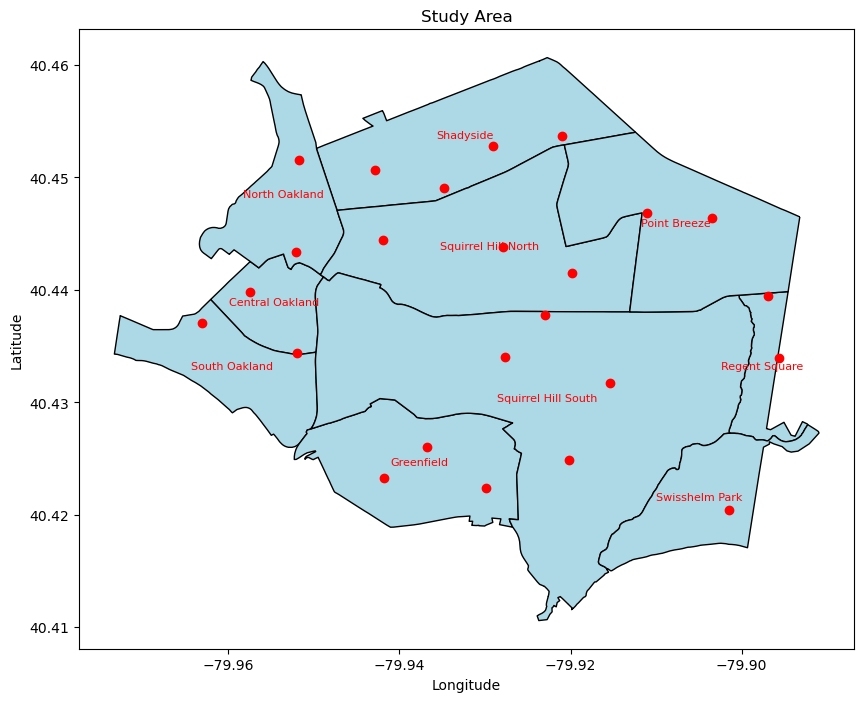

In [6]:
import pandas as pd
from shapely import wkt
neighborhoods_gdf = gpd.read_file(config['paths']['data']['neighborhoods_in'])
hoods_keep_gdf = neighborhoods_gdf[neighborhoods_gdf['hood'].isin(config['geography']['neighborhoods'])]
# Plot the GeoDataFrame
fig, ax = plt.subplots(figsize=(10, 10))
hoods_keep_gdf.plot(ax=ax, color='lightblue', edgecolor='black')

# Add neighborhood names to the plot
for idx, row in hoods_keep_gdf.iterrows():
    plt.annotate(text=row['hood'], xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                 horizontalalignment='center', fontsize=8, color='red')
bs_path = Path().resolve()/ 'data' / 'network' / 'raw' / 'bikeshare_candidates_mymaps.csv'
bikeshare_candidates = pd.read_csv(bs_path)
bikeshare_gdf = gpd.GeoDataFrame(bikeshare_candidates, geometry=bikeshare_candidates['WKT'].apply(wkt.loads), crs='EPSG:4326').reset_index()[['index','geometry']]
bikeshare_gdf.rename(columns={'index':'id'}, inplace=True)

bikeshare_gdf.plot(ax=ax, color='red')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Study Area')
plt.show()

# Extract Longitude and Latitude from the geometry column
bikeshare_gdf['Longitude'] = bikeshare_gdf.geometry.x
bikeshare_gdf['Latitude'] = bikeshare_gdf.geometry.y

# Create a new DataFrame with the required columns
bikeshare_gdf = bikeshare_gdf[['geometry', 'id', 'Longitude', 'Latitude']]
bikeshare_gdf.head()
bikeshare_path = config['paths']['data']['bikeshare_station']
bikeshare_gdf.to_csv(bikeshare_path, index=False)

In [5]:
print(len(bikeshare_candidates))

24


In [37]:
import re
import pickle
from itertools import combinations

import networkx as nx 
import numpy as np
from shapely import Point
import geopandas as gpd

from nomad import utils
from nomad import conf

zones_gdf = gpd.read_file(config['paths']['data']['microtransit_zones']).to_crs('EPSG:4326')
graphs_folder = Path().parent.absolute().resolve() / 'graphs'
with open(graphs_folder / 'graph_sn.pkl', 'rb') as inp:
    G_sn = pickle.load(inp)

nid_map = G_sn.nid_map
points = [Point(point) for point in G_sn.coord_matrix] # nodes in the graph
gdf_points = gpd.GeoDataFrame(geometry=points, crs='EPSG:4326')

mt_edges = {}

# Check each zone and find points inside
for idx, zone in enumerate(zones_gdf['geometry']):
    nids_inside = gdf_points[gdf_points.geometry.within(zone)].index.tolist()
    fixed_nodes_inside = [nid for nid in nids_inside if utils.mode(nid_map[nid]) in G_sn.fix_pre + ['org','dst']]
    
    # Construct an edge between any two fixed points within a service zone
    # TODO: Remove edges org-org and dst-dst even though technically they are both fixed points
    edge_pairs = list(combinations(fixed_nodes_inside, 2))            
    for edge in edge_pairs:
        edge_name = (nid_map[edge[0]], nid_map[edge[1]])
        # Define the length, mode type, edge type, and zone number of each edge
        attr_dict = {'length_m': G_sn.gcd_dist[edge[0], edge[1]], 'mode_type': 'mt', 'etype': 'mt', 'zones': [idx]}
        
        if edge_name in mt_edges:
            mt_edges[edge_name]['zones'].append(idx)
        else:
            mt_edges[edge_name] = attr_dict

# # Add the edges to the graph object
# mt_edges = [(e[0], e[1], mt_edges[e]) for e in mt_edges.keys()]
# G_sn.graph.add_edges_from(mt_edges)

In [38]:
mt_edges

{('bsd3', 'bsd4'): {'length_m': 1885.0,
  'mode_type': 'mt',
  'etype': 'mt',
  'zones': [0]},
 ('bsd3', 'ps12097'): {'length_m': 447.2,
  'mode_type': 'mt',
  'etype': 'mt',
  'zones': [0, 5]},
 ('bsd3', 'ps20990'): {'length_m': 419.8,
  'mode_type': 'mt',
  'etype': 'mt',
  'zones': [0, 5]},
 ('bsd3', 'ps12094'): {'length_m': 1370.0,
  'mode_type': 'mt',
  'etype': 'mt',
  'zones': [0, 5]},
 ('bsd3', 'ps12090'): {'length_m': 1347.0,
  'mode_type': 'mt',
  'etype': 'mt',
  'zones': [0, 5]},
 ('bsd3', 'ps2558'): {'length_m': 1025.0,
  'mode_type': 'mt',
  'etype': 'mt',
  'zones': [0, 5]},
 ('bsd3', 'ps17733'): {'length_m': 529.0,
  'mode_type': 'mt',
  'etype': 'mt',
  'zones': [0, 5]},
 ('bsd3', 'ps18398'): {'length_m': 499.0,
  'mode_type': 'mt',
  'etype': 'mt',
  'zones': [0, 5]},
 ('bsd3', 'ps12089'): {'length_m': 711.0,
  'mode_type': 'mt',
  'etype': 'mt',
  'zones': [0, 5]},
 ('bsd3', 'ps12095'): {'length_m': 749.0,
  'mode_type': 'mt',
  'etype': 'mt',
  'zones': [0, 5]},
 ('

/tmp/ipykernel_12925/2198705298.py:79: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


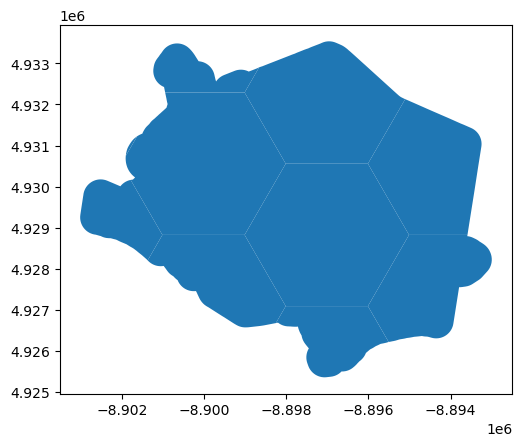

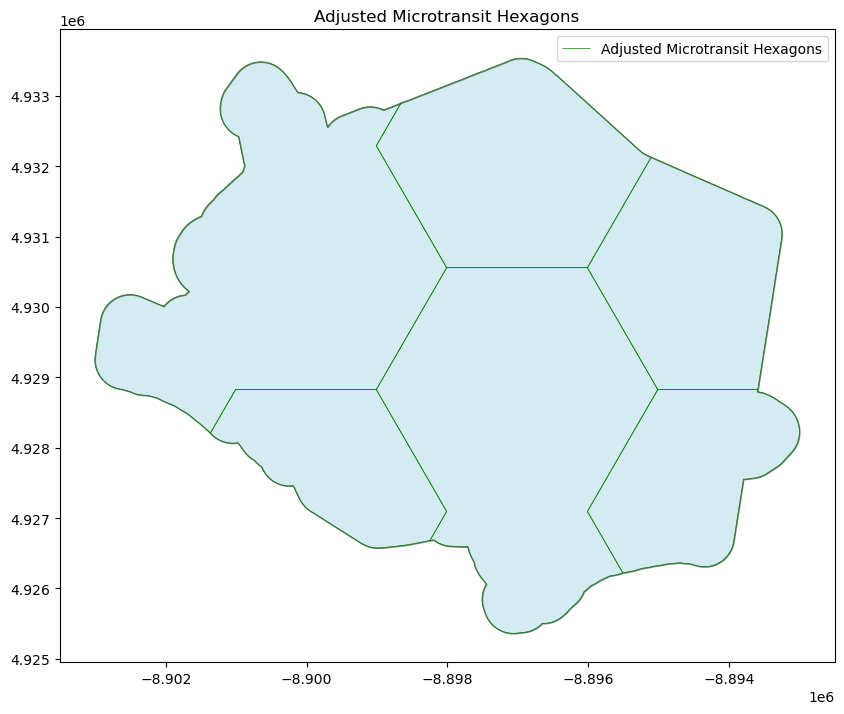

(6, 3)


In [177]:
from shapely.ops import unary_union

# Load GeoDataFrame
study_area_gdf = gpd.read_file(config['paths']['data']['study_area_out']).to_crs("EPSG:3857")

# Define hexagon radii  (in the same units as study area CRS)
bikeshare_hex_size = 1500  # 1 km radius for bikeshare
microtransit_hex_size = 2000  # 4 km radius for microtransit

# Generate hexagonal grid for bikeshare
bikeshare_hex_grid = create_hex_grid(study_area_gdf.total_bounds, bikeshare_hex_size)
bikeshare_hex_grid = bikeshare_hex_grid.set_crs(study_area_gdf.crs, allow_override=True)
bikeshare_hex_grid_clipped = gpd.overlay(bikeshare_hex_grid, study_area_gdf, how='intersection')

# Generate centroids for bikeshare
bikeshare_hex_grid_clipped['centroid'] = bikeshare_hex_grid_clipped.geometry.centroid
bikeshare_centroids_gdf = bikeshare_hex_grid_clipped[['centroid']].copy().rename(columns={'centroid': 'geometry'})
bikeshare_centroids_gdf = gpd.GeoDataFrame(bikeshare_centroids_gdf, geometry='geometry', crs=bikeshare_hex_grid_clipped.crs)
#Save to CSV or Shapefile if needed
folder = 'project3-network_opt'
bikeshare_path = Path().resolve() / folder / 'data' / 'network' / 'raw' / 'bikeshare_candidates.csv'
#bikeshare_centroids_gdf.to_csv(bikeshare_path, index=False)


# # Make the same set of candidates for scooter stations and save as scooter_candidates.csv
# scooter_gdf = bikeshare_gdf.copy()
# scooter_path = Path().resolve() / folder / 'data' / 'network' / 'raw' / 'scooter_candidates.csv'
# scooter_gdf.to_csv(scooter_path, index=False)


# Generate hexagonal grid for microtransit
microtransit_hex_grid = create_hex_grid(study_area_gdf.total_bounds, microtransit_hex_size)
microtransit_hex_grid = microtransit_hex_grid.set_crs(study_area_gdf.crs, allow_override=True)
microtransit_hex_grid_clipped = gpd.overlay(microtransit_hex_grid, study_area_gdf, how='intersection').reset_index(drop=True)

# Add an ID column for microtransit hexagons
microtransit_hex_grid_clipped.insert(0, 'id', microtransit_hex_grid_clipped.index)

microtransit_hex_grid_clipped.plot()

# Calculate area of each hexagon
microtransit_hex_grid_clipped['area'] = microtransit_hex_grid_clipped.geometry.area


# Identify small microtransit service areas and merge with their small neighbors
small_hexagons = microtransit_hex_grid_clipped[microtransit_hex_grid_clipped['area'] < 10392000/2.5]

# Iterate over small hexagons
for small_hex_id in small_hexagons['id']:
    # Spatial join to find neighbors for small hexagons
    neighbors = gpd.sjoin(small_hexagons, microtransit_hex_grid_clipped, predicate='intersects')

    small_hex = microtransit_hex_grid_clipped.loc[small_hex_id]

    # Find its neighbors
    small_neighbors = neighbors[neighbors['id_left'] == small_hex_id]

    # Exclude the small hexagon itself
    small_neighbors = small_neighbors[small_neighbors['id_right'] != small_hex_id].reset_index(drop=True)

    # Find the smallest neighbor
    smallest_neighbor_id = small_neighbors.loc[small_neighbors['area_right'].idxmax(), 'id_right']

    # Merge the small hexagon into its largest neighbor
    smallest_neighbor = microtransit_hex_grid_clipped.loc[smallest_neighbor_id]
    merged_geometry = unary_union([small_hex.geometry, smallest_neighbor.geometry])

    # Update the GeoDataFrame
    microtransit_hex_grid_clipped.at[smallest_neighbor_id, 'geometry'] = merged_geometry
    microtransit_hex_grid_clipped.drop(index=small_hex_id, inplace=True)

# Recalculate area for updated geometries
microtransit_hex_grid_clipped['area'] = microtransit_hex_grid_clipped.geometry.area

# Visualization after adjustment
fig, ax = plt.subplots(figsize=(10, 10))
microtransit_hex_grid_clipped.boundary.plot(ax=ax, color='green', linewidth=0.5, label='Adjusted Microtransit Hexagons')
study_area_gdf.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.5, label='Study Area')
ax.legend()
ax.set_title("Adjusted Microtransit Hexagons")
plt.show()

# Get microtransit service zone candidates. Simply choose all hexagons
microtransit_grid = microtransit_hex_grid_clipped.copy().reset_index(drop=True)
microtransit_grid['id'] = microtransit_grid.index
mt_path = Path().resolve() / folder / 'data' / 'network' / 'raw' / 'microtransit_candidates.shp'
#microtransit_grid[['id','geometry']].to_file(mt_path, driver='GeoJSON')
print(microtransit_grid.shape)